# MLP t12026 Kaggle Project
## Name: Nitish Bhatt
## Roll Number: 24f2001383

This notebook follows a structured machine learning pipeline:
1. Data Loading & Inspection
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Preprocessing via Scikit-Learn Pipelines
5. Model Training & Validation
6. Threshold Optimization for Class Imbalance
7. Final Ensemble & Submission

# 1. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

import lightgbm as lgb
from xgboost import XGBClassifier

# 2. Data Loading

In [2]:
print("Loading data...")
train_df = pd.read_csv("/kaggle/input/competitions/comment-category-prediction-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/comment-category-prediction-challenge/test.csv")
sample_df = pd.read_csv("/kaggle/input/competitions/comment-category-prediction-challenge/Sample.csv")

print(f"Train Shape: {train_df.shape}")
print(f"Test Shape: {test_df.shape}")

Loading data...
Train Shape: (198000, 15)
Test Shape: (102000, 14)


# 3. Exploratory Data Analysis (EDA)
In this section, we analyze the distribution of our target variable and features to make informed decisions for preprocessing.

## 3.1 Target Variable Distribution

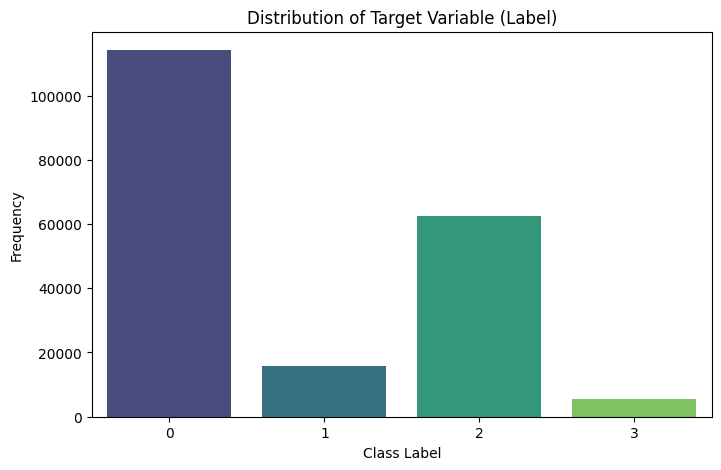

In [3]:
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='label', palette='viridis')
plt.title("Distribution of Target Variable (Label)")
plt.xlabel("Class Label")
plt.ylabel("Frequency")
plt.show()

### Insight: 
The dataset is highly imbalanced. Label 0 is the majority, while Label 1 and 3 are minority classes.

### Decision: 
We must use Stratified splitting, Macro F1 for evaluation, and class threshold optimization.


## 3.2 Missing Data Check

In [4]:
missing_counts = train_df.isnull().sum()
print("Missing values in Training Data:\n", missing_counts[missing_counts > 0])

Missing values in Training Data:
 race        145423
religion    145423
gender      145423
comment          1
dtype: int64


### Insight:
Categorical columns (race, religion, gender) have significant missing data. 

### Decision:
We will impute missing categorical values with the string 'missing'.

## 3.3 Numerical Feature Descriptive Analysis & Skewness Check 

In [5]:
train_df.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


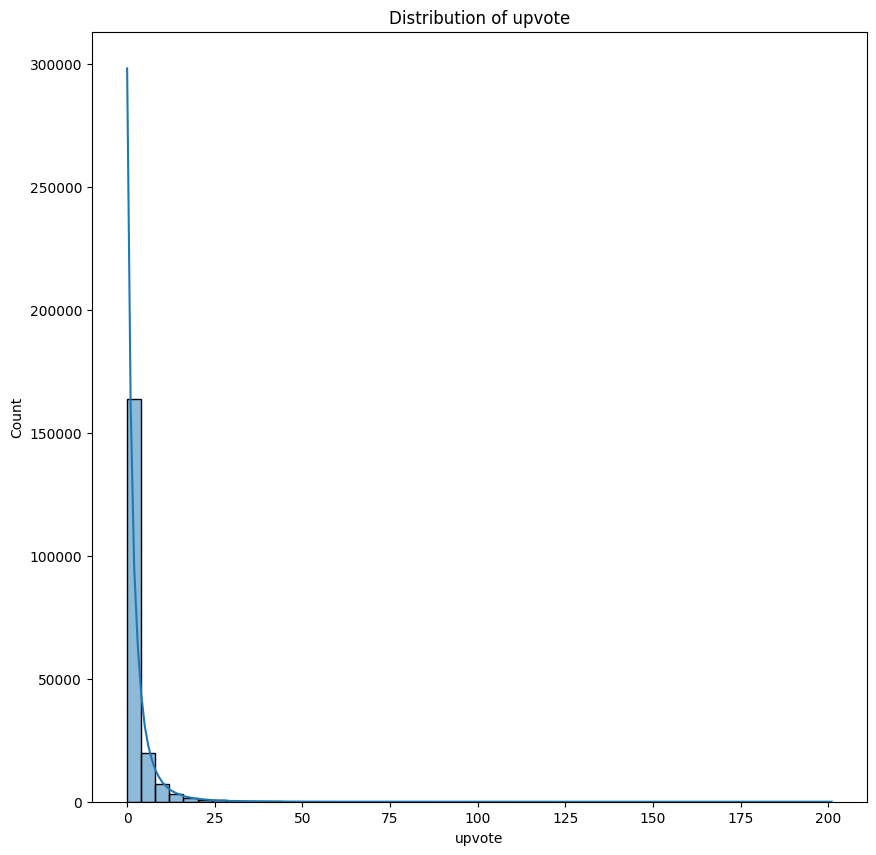

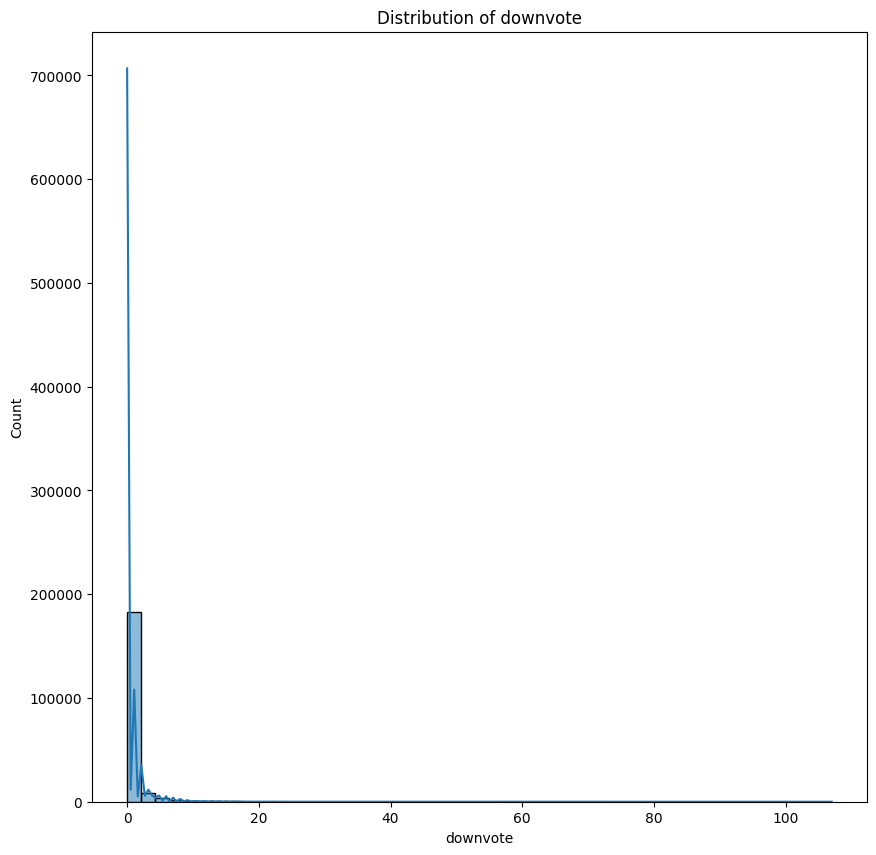

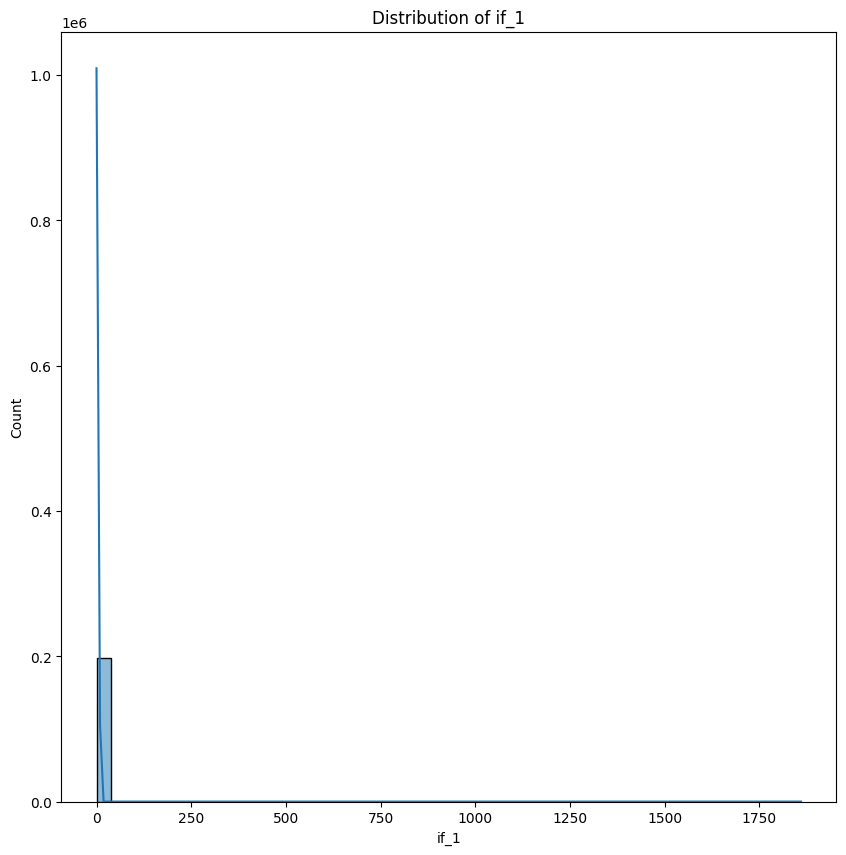

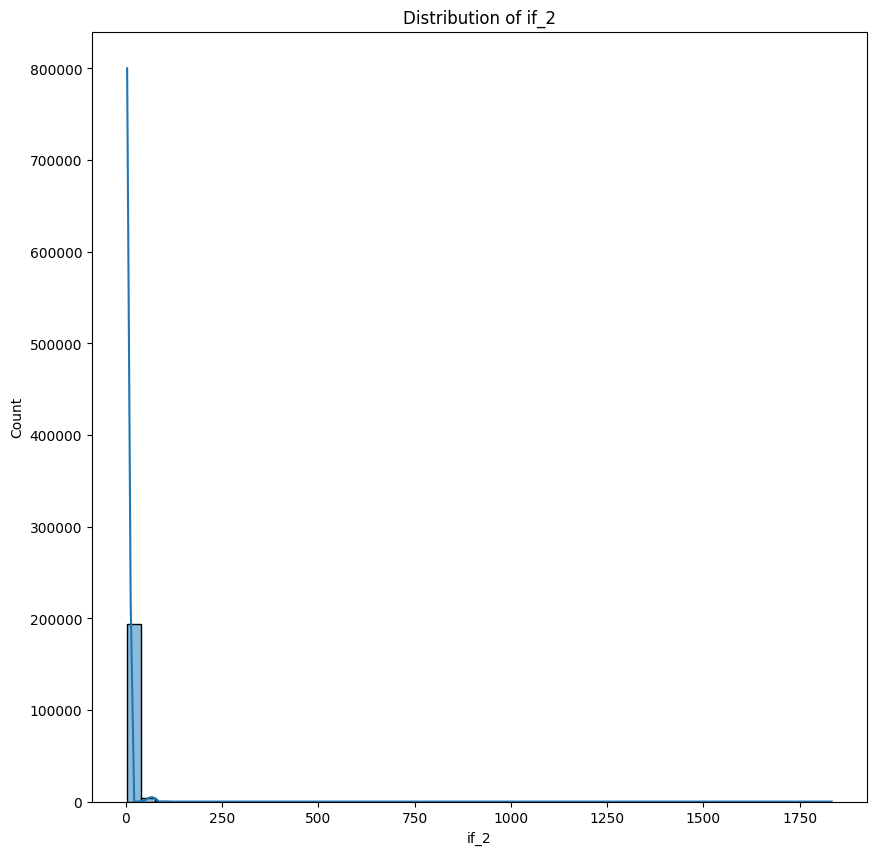

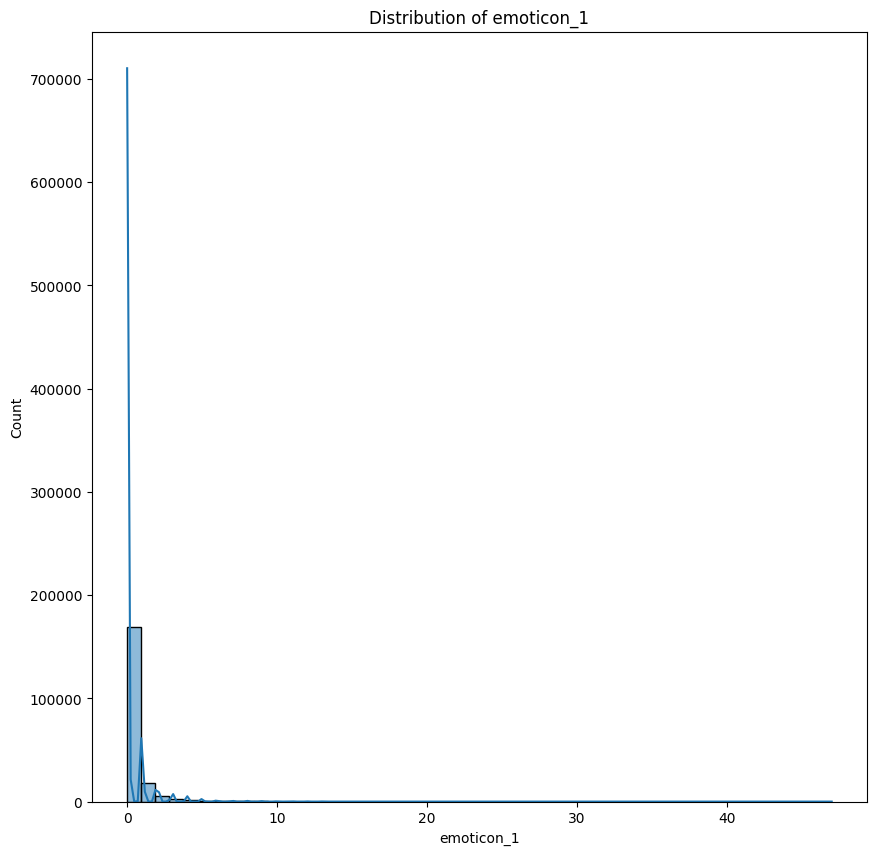

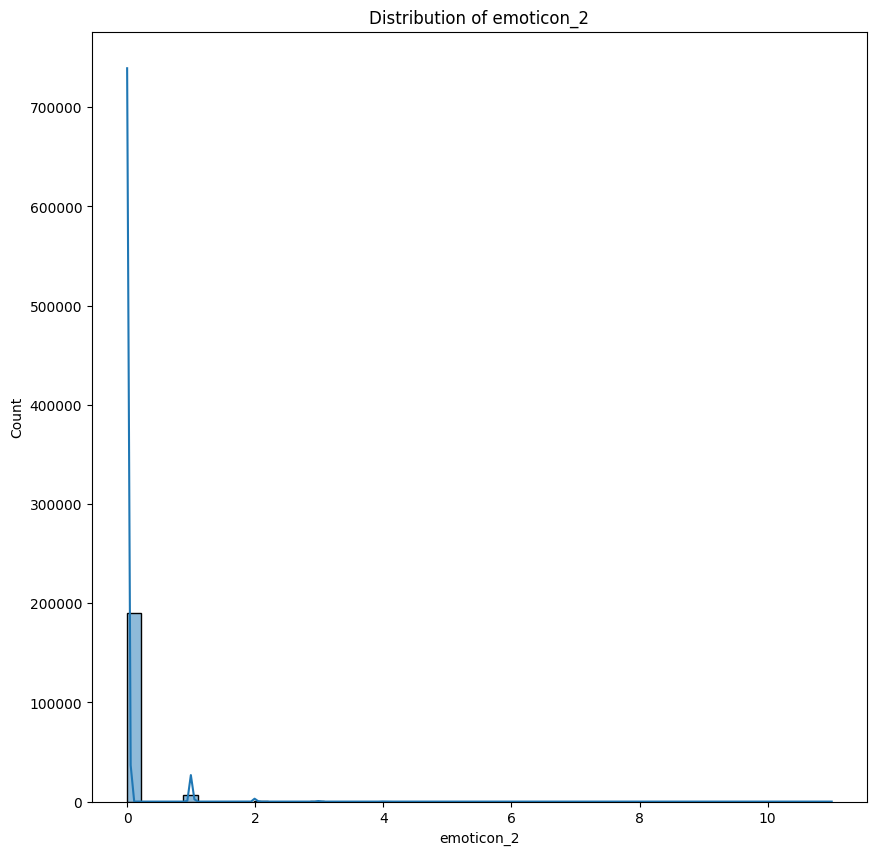

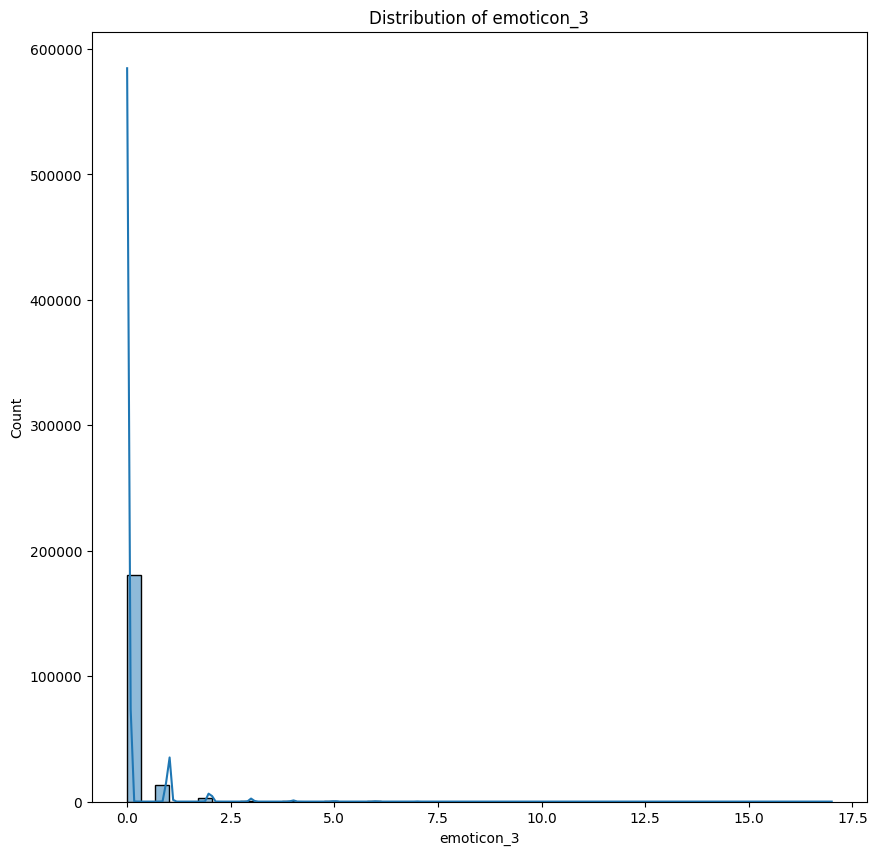

In [6]:
numerical_cols = ['upvote', 'downvote', 'if_1', 'if_2', "emoticon_1", "emoticon_2", "emoticon_3"]
train_df[numerical_cols].skew()

for col in numerical_cols:
    plt.figure(figsize=(10,10))
    sns.histplot(train_df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

### Insight: 
- Numerical features are heavily right-skewed with extreme outliers.
- Most values are concentrated about 0

### Decision: 
Apply logarithmic transformation (log1p) to normalize numerical distributions.

# 4. Feature Engineering
We will create a function to apply row-wise feature engineering. This ensures both train and test data receive identical features.


In [7]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def engineer_features(df):
    df_new = df.copy()
    
    # 1. Text properties
    df_new["comment"] = df_new["comment"].fillna("")
    df_new["char_length"] = df_new["comment"].str.len()
    
    # Simple word count
    word_counts = []
    for text in df_new["comment"]:
        word_counts.append(len(str(text).split()))
    df_new["word_count"] = word_counts
    
    df_new["exclamation_count"] = df_new["comment"].str.count("!")
    df_new["question_count"] = df_new["comment"].str.count(r"\?")
    df_new["upper_ratio"] = df_new["comment"].str.count(r"[A-Z]") / (df_new["char_length"] + 1)
    
    # 2. Apply Text cleaning IN-PLACE on the 'comment' column
    df_new["comment"] = df_new["comment"].apply(clean_text)
    
    # 3. Engagement metrics
    df_new["total_votes"] = df_new["upvote"] + df_new["downvote"]
    df_new["vote_ratio"] = df_new["upvote"] / (df_new["downvote"] + 1)
    df_new["total_emoticons"] = df_new["emoticon_1"] + df_new["emoticon_2"] + df_new["emoticon_3"]
    
    # 4. Date Features
    if "created_date" in df_new.columns:
        df_new["created_date"] = pd.to_datetime(df_new["created_date"], errors="coerce")
        df_new["hour"] = df_new["created_date"].dt.hour.fillna(0).astype(int)
        df_new["day_of_week"] = df_new["created_date"].dt.dayofweek.fillna(0).astype(int)
        df_new["month"] = df_new["created_date"].dt.month.fillna(0).astype(int)
    
    # 5. Identity flags and crosses
    df_new["is_identity_hidden"] = ((df_new["race"].isna()) | (df_new["religion"].isna()) | (df_new["gender"].isna())).astype(int)
    df_new["race_religion"] = df_new["race"].astype(str) + "_" + df_new["religion"].astype(str)
    df_new["race_gender"] = df_new["race"].astype(str) + "_" + df_new["gender"].astype(str)
    
    # Drop raw IDs and date
    cols_to_drop = ["created_date", "post_id"]
    df_new = df_new.drop(columns=[c for c in cols_to_drop if c in df_new.columns])
        
    return df_new

print("Engineering features...")
train_fe = engineer_features(train_df)
test_fe = engineer_features(test_df)

Engineering features...


# 5. Train - Validation Split
We use a stratified split to ensure validation data has the same class distribution as the training data.


In [8]:
x_full = train_fe.drop(columns=["label"])
y_full = train_fe["label"]

x_train, x_val, y_train, y_val = train_test_split(
    x_full, y_full, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_full
)

print("x_train shape:", x_train.shape)
print("x_val shape:", x_val.shape)

x_train shape: (158400, 26)
x_val shape: (39600, 26)


# 6. Preprocessing Pipeline
Using Scikit-Learn pipelines prevents data leakage. The transformers are fit ONLY on x_train, and then applied to x_val and test sets.


In [9]:
# Define column groups
text_col = "comment"

num_cols = [
    "upvote", "downvote", "if_1", "if_2",
    "char_length", "word_count", "exclamation_count", 
    "question_count", "upper_ratio", "total_votes", 
    "vote_ratio", "total_emoticons", "hour", "day_of_week", "month"
]

cat_cols = [
    "race", "religion", "gender", "disability",
    "race_religion", "race_gender", "is_identity_hidden"
]

def log_transform(x):
    return np.log1p(x)

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('log_transform', FunctionTransformer(log_transform, validate=False)),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('word_tfidf', TfidfVectorizer(stop_words="english", ngram_range=(1, 2), max_features=10000), text_col),
    ('char_tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), max_features=5000), text_col),
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

print("Applying preprocessing pipelines...")
x_train_proc = preprocessor.fit_transform(x_train)
x_val_proc = preprocessor.transform(x_val)

Applying preprocessing pipelines...


# 7. Model Training & Evaluation
We will construct full pipelines for our three best models.

In [10]:
models = {
    "Logistic Regression": LogisticRegression(C=2.0, max_iter=1500, class_weight="balanced", n_jobs=-1, random_state=42),
    "LightGBM": lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=64, class_weight="balanced", n_jobs=-1, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, tree_method="hist", objective="multi:softprob", num_class=4, n_jobs=-1, random_state=42),
    "LinearSVC": CalibratedClassifierCV(LinearSVC(C=1.0, class_weight='balanced', random_state=42))
}

val_probs_dict = {}
class_f1_scores = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(x_train_proc, y_train)
    
    probs = model.predict_proba(x_val_proc)
    val_probs_dict[name] = probs
    
    preds = np.argmax(probs, axis=1)
    acc = accuracy_score(y_val, preds)
    macro_f1 = f1_score(y_val, preds, average="macro")
    
    print(f"{name} | Accuracy: {acc:.4f} | Macro F1: {macro_f1:.4f}")
    
    # Store class-wise F1 scores
    report = classification_report(y_val, preds, output_dict=True)
    class_f1_scores[name] = [report[str(i)]['f1-score'] for i in range(4)]


Training Logistic Regression...
Logistic Regression | Accuracy: 0.8959 | Macro F1: 0.7884

Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 13.303399 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2023769
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 15098
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
LightGBM | Accuracy: 0.9116 | Macro F1: 0.8173

Training XGBoost...
XGBoost | Accuracy: 0.9077 | Macro F1: 0.7793

Training LinearSVC...
LinearSVC | Accuracy: 0.9057 | Macro F1: 0.7894


# 8. Model Ensembling & Threshold Optimization
We will blend the probabilities of our models. Because of class imbalance, standard argmax (which assumes a 0.25 threshold for 4 classes) underperforms. We use optimization to find the mathematical best thresholds.


In [11]:
print("\nApplying Class-Wise F1 Weighting...")

blended_val_probs = np.zeros_like(val_probs_dict["LightGBM"])

for class_idx in range(4):
    f1_lr = class_f1_scores["Logistic Regression"][class_idx]
    f1_lgb = class_f1_scores["LightGBM"][class_idx]
    f1_xgb = class_f1_scores["XGBoost"][class_idx]
    
    total_f1 = f1_lr + f1_lgb + f1_xgb
    
    w_lr = f1_lr / total_f1
    w_lgb = f1_lgb / total_f1
    w_xgb = f1_xgb / total_f1
    
    blended_val_probs[:, class_idx] = (
        (val_probs_dict["Logistic Regression"][:, class_idx] * w_lr) +
        (val_probs_dict["LightGBM"][:, class_idx] * w_lgb) +
        (val_probs_dict["XGBoost"][:, class_idx] * w_xgb)
    )

ensemble_preds = np.argmax(blended_val_probs, axis=1)
print(f"Ensemble Macro F1: {f1_score(y_val, ensemble_preds, average='macro'):.4f}")
print("\nFinal Validation Classification Report:\n", classification_report(y_val, ensemble_preds))


Applying Class-Wise F1 Weighting...
Ensemble Macro F1: 0.8285

Final Validation Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.74      0.84      0.79      3183
           2       0.88      0.90      0.89     12488
           3       0.65      0.71      0.68      1094

    accuracy                           0.92     39600
   macro avg       0.81      0.85      0.83     39600
weighted avg       0.92      0.92      0.92     39600



# 9. Final Training and Submission
To maximize our Kaggle score, we retrain our pipelines on the entire training dataset (`x_full`, `y_full`), generate test probabilities, apply our learned thresholds, and export the submission.


In [12]:
print("\n--- Commencing Final Full-Data Retraining ---")

x_full_proc = preprocessor.fit_transform(x_full)
x_test_proc = preprocessor.transform(test_fe)

test_probs_dict = {}

for name, model in models.items():
    print(f"Retraining {name} on full dataset...")
    model.fit(x_full_proc, y_full)
    test_probs_dict[name] = model.predict_proba(x_test_proc)

blended_test_probs = np.zeros_like(test_probs_dict["LightGBM"])

for class_idx in range(4):
    f1_lr = class_f1_scores["Logistic Regression"][class_idx]
    f1_lgb = class_f1_scores["LightGBM"][class_idx]
    f1_xgb = class_f1_scores["XGBoost"][class_idx]
    
    total_f1 = f1_lr + f1_lgb + f1_xgb
    
    w_lr = f1_lr / total_f1
    w_lgb = f1_lgb / total_f1
    w_xgb = f1_xgb / total_f1
    
    blended_test_probs[:, class_idx] = (
        (test_probs_dict["Logistic Regression"][:, class_idx] * w_lr) +
        (test_probs_dict["LightGBM"][:, class_idx] * w_lgb) +
        (test_probs_dict["XGBoost"][:, class_idx] * w_xgb)
    )

final_test_preds = np.argmax(blended_test_probs, axis=1)

print("\nSaving submission.csv...")
submission = pd.DataFrame({
    sample_df.columns[0]: sample_df[sample_df.columns[0]],
    sample_df.columns[1]: final_test_preds
})

submission.to_csv("submission.csv", index=False)
print("Submission file successfully generated!")


--- Commencing Final Full-Data Retraining ---
Retraining Logistic Regression on full dataset...
Retraining LightGBM on full dataset...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 18.380726 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2146716
[LightGBM] [Info] Number of data points in the train set: 198000, number of used features: 15100
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Retraining XGBoost on full dataset...
Retraining LinearSVC on full dataset...

Saving submission.csv...
Submission file successfully generated!
